In [1]:
import os
import sys
from pathlib import Path

# Ensure working directory is project root
PROJECT_ROOT = Path(r"C:\Users\amand\OneDrive - Fisk University\Documents\ResumeBiasResearch")
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_faircvdb

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

data = load_faircvdb('data/raw')
print(f"\nWorking directory: {os.getcwd()}")

FairCVdb loaded successfully.
Available keys: ['Profiles Train', 'Profiles Test', 'Bios Train', 'Bios Test', 'Names Train', 'Names Test', 'Blind Labels Train', 'Blind Labels Test', 'Biased Labels Train (Gender)', 'Biased Labels Test (Gender)', 'Biased Labels Train (Ethnicity)', 'Biased Labels Test (Ethnicity)', 'Image List Train', 'Image List Test']

Working directory: C:\Users\amand\OneDrive - Fisk University\Documents\ResumeBiasResearch



Blind (Unbiased):
  Range: [0.000, 0.923]
  Mean: 0.419
  Std: 0.127
  Unique values (first 10): [0.         0.02429076 0.03346978 0.03494953 0.04376022 0.04719362
 0.05711331 0.06011602 0.06063447 0.0646105 ]
  Total unique values: 19200

Gender-Biased:
  Range: [0.000, 0.900]
  Mean: 0.371
  Std: 0.135
  Unique values (first 10): [0.         0.00080581 0.00491406 0.00521098 0.00609658 0.00939307
 0.01085359 0.01152028 0.01174355 0.01308276]
  Total unique values: 19181

Ethnicity-Biased:
  Range: [0.000, 1.000]
  Mean: 0.419
  Std: 0.149
  Unique values (first 10): [0.         0.00075643 0.00166701 0.00238912 0.00460436 0.00608485
 0.00713124 0.01381646 0.01383283 0.01618335]
  Total unique values: 19186


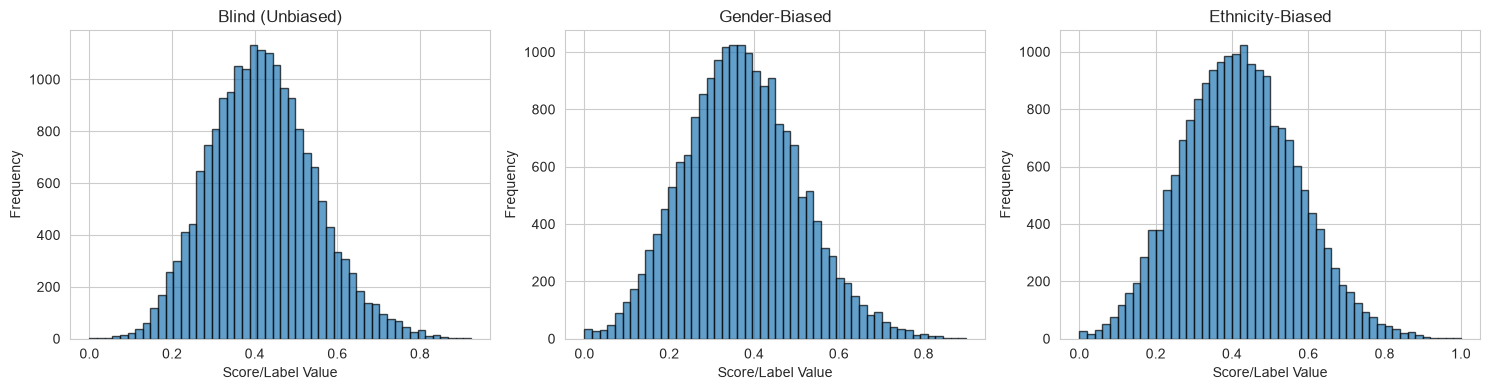

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

label_keys = [
    ('Blind Labels Train', 'Blind (Unbiased)'),
    ('Biased Labels Train (Gender)', 'Gender-Biased'),
    ('Biased Labels Train (Ethnicity)', 'Ethnicity-Biased')
]

for ax, (key, title) in zip(axes, label_keys):
    labels = np.asarray(data[key]).squeeze()
    unique_vals = np.unique(labels)
    print(f"\n{title}:")
    print(f"  Range: [{labels.min():.3f}, {labels.max():.3f}]")
    print(f"  Mean: {labels.mean():.3f}")
    print(f"  Std: {labels.std():.3f}")
    print(f"  Unique values (first 10): {unique_vals[:10]}")
    print(f"  Total unique values: {len(unique_vals)}")

    ax.hist(labels, bins=50, edgecolor='black', alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel('Score/Label Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('results/figures/01_label_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

In [3]:
profiles = data['Profiles Train']
names = data['Names Train']
bios = data['Bios Train']

print("=== Profile array properties ===")
print(f"Shape: {profiles.shape}")
print(f"Data type: {profiles.dtype}")
print(f"Min value: {profiles.min():.3f}")
print(f"Max value: {profiles.max():.3f}")
print(f"Mean value: {profiles.mean():.3f}")

# Check how many features are binary, categorical, continuous
sample_cols = profiles[:100]
unique_counts = [len(np.unique(sample_cols[:, i])) for i in range(profiles.shape[1])]
print(f"\nFeature cardinality (unique values per feature, first 100 samples):")
print(f"  Binary features (2 unique): {sum(1 for u in unique_counts if u == 2)}")
print(f"  Low-cardinality (3-10):     {sum(1 for u in unique_counts if 3 <= u <= 10)}")
print(f"  Continuous (>10):           {sum(1 for u in unique_counts if u > 10)}")

print("\n=== First 5 names ===")
for n in names[:5]:
    print(f"  {n}")

print("\n=== First 3 bios (showing both variants) ===")
for i in range(3):
    print(f"\n--- Candidate {i+1}: {names[i]} ---")
    print(f"  Variant A (with name): {bios[i][0][:200]}...")
    print(f"  Variant B (anonymized): {bios[i][1][:200]}...")

=== Profile array properties ===
Shape: (19200, 51)
Data type: float64
Min value: -0.721
Max value: 9.000
Mean value: 0.236

Feature cardinality (unique values per feature, first 100 samples):
  Binary features (2 unique): 2
  Low-cardinality (3-10):     9
  Continuous (>10):           40

=== First 5 names ===
  Pim
  Jane
  Henry
  Christin
  Amy

=== First 3 bios (showing both variants) ===

--- Candidate 1: Pim ---
  Variant A (with name):  With a look and feel that is colourful, powerful and energetic, Pim also takes great pleasure in capturing the raw moments in life - as can be seen in his street photography....
  Variant B (anonymized): With a look and feel that is colourful, powerful and energetic, _ also takes great pleasure in capturing the raw moments in life - as can be seen in _ street photography....

--- Candidate 2: Jane ---
  Variant A (with name):  Alexis Xenakis is the publisher of Knitter's Magazine and XRX Books. His photography is featured in more than 15 books, 

Correlations between label types:
  Blind vs Gender-biased:    0.9330
  Blind vs Ethnicity-biased: 0.8549
  Gender vs Ethnicity:       0.7981

Bias gap statistics (Biased - Blind):
  Gender bias gap:    mean=-0.0472, std=0.0487
  Ethnicity bias gap: mean=+0.0000, std=0.0774


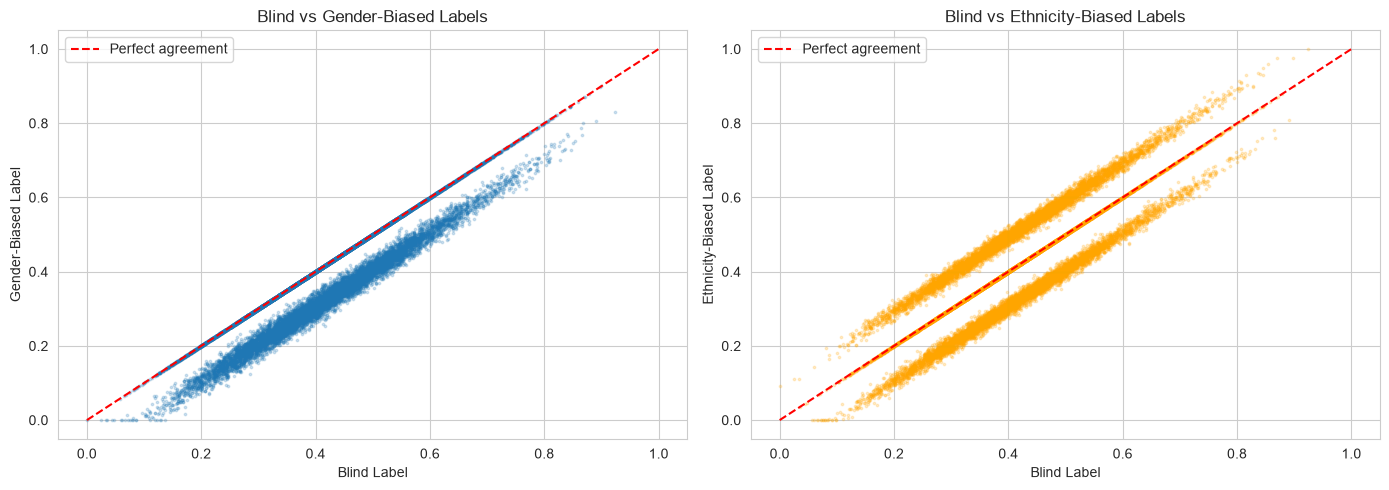

In [4]:
blind = np.asarray(data['Blind Labels Train']).squeeze()
gender_biased = np.asarray(data['Biased Labels Train (Gender)']).squeeze()
ethnicity_biased = np.asarray(data['Biased Labels Train (Ethnicity)']).squeeze()

print("Correlations between label types:")
print(f"  Blind vs Gender-biased:    {np.corrcoef(blind, gender_biased)[0,1]:.4f}")
print(f"  Blind vs Ethnicity-biased: {np.corrcoef(blind, ethnicity_biased)[0,1]:.4f}")
print(f"  Gender vs Ethnicity:       {np.corrcoef(gender_biased, ethnicity_biased)[0,1]:.4f}")

print("\nBias gap statistics (Biased - Blind):")
print(f"  Gender bias gap:    mean={np.mean(gender_biased - blind):+.4f}, std={np.std(gender_biased - blind):.4f}")
print(f"  Ethnicity bias gap: mean={np.mean(ethnicity_biased - blind):+.4f}, std={np.std(ethnicity_biased - blind):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(blind, gender_biased, alpha=0.2, s=3)
axes[0].plot([0, 1], [0, 1], 'r--', label='Perfect agreement')
axes[0].set_xlabel('Blind Label')
axes[0].set_ylabel('Gender-Biased Label')
axes[0].set_title('Blind vs Gender-Biased Labels')
axes[0].legend()

axes[1].scatter(blind, ethnicity_biased, alpha=0.2, s=3, color='orange')
axes[1].plot([0, 1], [0, 1], 'r--', label='Perfect agreement')
axes[1].set_xlabel('Blind Label')
axes[1].set_ylabel('Ethnicity-Biased Label')
axes[1].set_title('Blind vs Ethnicity-Biased Labels')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/figures/02_label_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

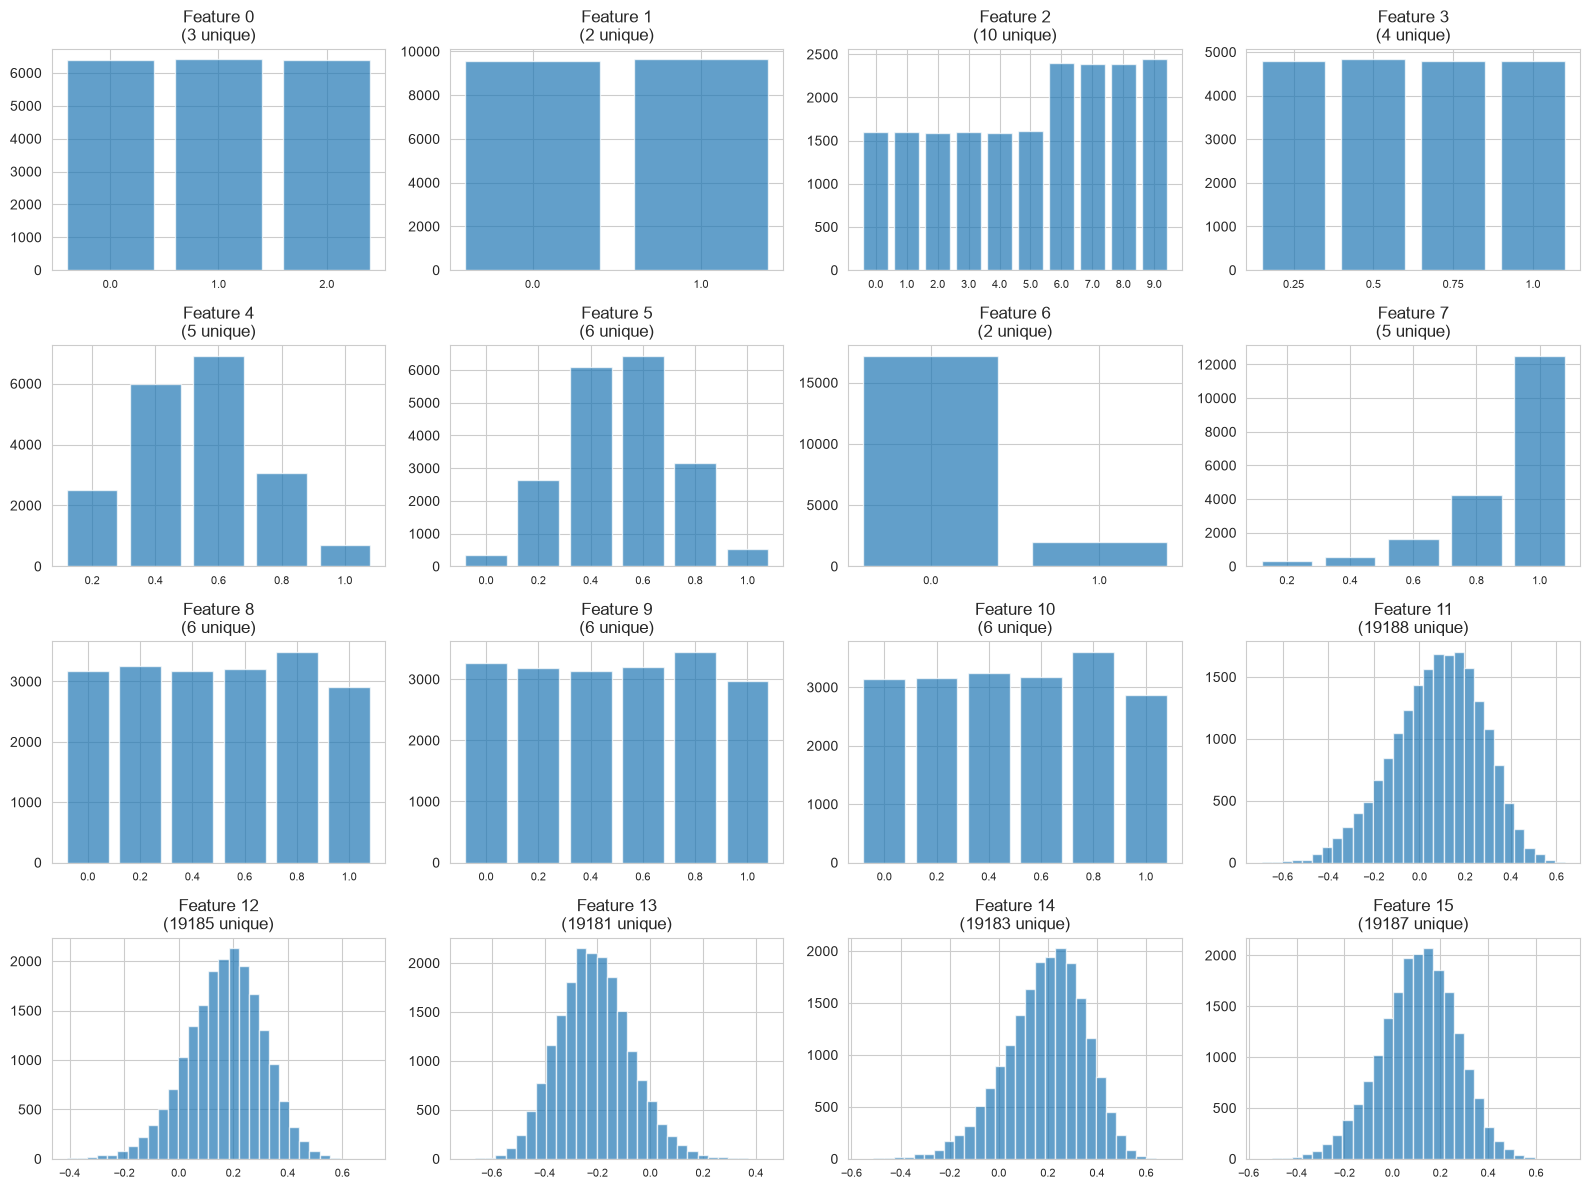

In [5]:
# Visualize the distribution of the first 16 features
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i in range(16):
    ax = axes[i]
    vals = profiles[:, i]
    unique_vals = np.unique(vals)
    if len(unique_vals) <= 10:
        # Bar chart for categorical/binary
        counts = pd.Series(vals).value_counts().sort_index()
        ax.bar(counts.index.astype(str), counts.values, alpha=0.7)
    else:
        # Histogram for continuous
        ax.hist(vals, bins=30, alpha=0.7)
    ax.set_title(f"Feature {i}\n({len(unique_vals)} unique)")
    ax.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.savefig('results/figures/03_feature_distributions.png', dpi=100, bbox_inches='tight')
plt.show()